In [1]:
import pandas as pd

data = {
    "study_hours": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 2, 4, 6, 8, 3, 5, 7, 9],
    "attendance": [50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 40, 60, 78, 88, 58, 72, 82, 92],
    "homework_rate": [30, 40, 50, 55, 65, 70, 80, 85, 90, 95, 20, 45, 75, 92, 48, 68, 83, 91],
    "pass_exam": [0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1]
}

df = pd.DataFrame(data)
df

,study_hours,attendance,homework_rate,pass_exam
0,1,50,30,0
1,2,55,40,0
2,3,60,50,0
3,4,65,55,0
4,5,70,65,1
5,6,75,70,1
6,7,80,80,1
7,8,85,85,1
8,9,90,90,1
9,10,95,95,1


In [2]:
X = df[["study_hours", "attendance", "homework_rate"]]
y = df["pass_exam"]

print(X.head())
print(y.head())

   study_hours  attendance  homework_rate
0            1          50             30
1            2          55             40
2            3          60             50
3            4          65             55
4            5          70             65
0    0
1    0
2    0
3    0
4    1
Name: pass_exam, dtype: int64


In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42
)

print("训练集数量：", len(X_train))
print("测试集数量：", len(X_test))

训练集数量： 13
测试集数量： 5


In [4]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=3,
    random_state=42
)

rf_model.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap:

In [5]:
y_pred = rf_model.predict(X_test)

print("真实结果：", [int(x) for x in y_test])
print("预测结果：", [int(x) for x in y_pred])

真实结果： [0, 0, 1, 1, 0]
预测结果： [0, 0, 1, 1, 0]


In [6]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy = float(accuracy_score(y_test, y_pred))
print(f"准确率：{accuracy:.2f}")

print("混淆矩阵：")
print(confusion_matrix(y_test, y_pred).tolist())

print("分类报告：")
print(classification_report(y_test, y_pred, digits=2))

准确率：1.00
混淆矩阵：
[[3, 0], [0, 2]]
分类报告：
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       1.00      1.00      1.00         2

    accuracy                           1.00         5
   macro avg       1.00      1.00      1.00         5
weighted avg       1.00      1.00      1.00         5



In [7]:
feature_names_cn = {
    "study_hours": "学习时间",
    "attendance": "出勤率",
    "homework_rate": "作业完成率"
}

feature_importance = pd.DataFrame({
    "特征": [feature_names_cn[name] for name in X.columns],
    "importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="importance",
    ascending=False
)

feature_importance["importance"] = feature_importance["importance"].round(2)
feature_importance = feature_importance.rename(columns={"importance": "重要性"})

feature_importance

,特征,重要性
0,学习时间,0.36
1,出勤率,0.36
2,作业完成率,0.28


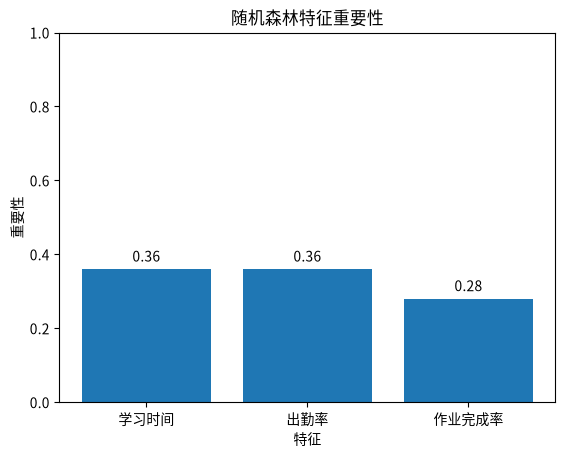

In [8]:
import matplotlib.pyplot as plt
from matplotlib import font_manager

# 直接加载中文字体，避免图表中的汉字显示为方框
font_path = "/home/penglei/.local/share/fonts/NotoSansCJKsc-Regular.otf"
font_manager.fontManager.addfont(font_path)
font_name = font_manager.FontProperties(fname=font_path).get_name()
plt.rcParams["font.sans-serif"] = [font_name]
plt.rcParams["axes.unicode_minus"] = False

plt.bar(feature_importance["特征"], feature_importance["重要性"])
plt.xlabel("特征")
plt.ylabel("重要性")
plt.title("随机森林特征重要性")
plt.ylim(0, 1)

for index, value in enumerate(feature_importance["重要性"]):
    plt.text(index, value + 0.02, f"{float(value):.2f}", ha="center")

plt.show()